# Bias-Variance Decomposition in Practice

Главный вопрос здесь практический. Насколько отчетливо учебный bias-variance trade-off проявляется у моделей с разными способами управления сложностью, если сравнивать их на одинаковых выборках?

Синтетическая часть нужна для прямого расчета компонентов ошибки. Реальные данные затем показывают, какая часть этой картины сохраняется, когда истинная функция уже неизвестна.


## Математическая постановка

Для squared loss и случайной обучающей выборки $D$ выполняется

$$
\mathbb{E}_{D,\varepsilon}[(Y-\hat f_D(x))^2]
=
(\mathbb{E}_D[\hat f_D(x)]-f(x))^2
+
\mathbb{V}_D[\hat f_D(x)]
+
\sigma^2.
$$

Средний прогноз оценивается по конечному числу повторов. Поэтому наивный squared bias содержит добавку $Variance/m$, которая вычитается в расчете. Одна evaluation grid используется для всех моделей и никогда не передается в `fit`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from bias_variance_project.core import bias_variance_decomposition, generate_training_sets
from bias_variance_project.experiments import DATA_SEED, MODEL_SEED, TEST_NOISE_SEED

ROOT = Path.cwd()
TABLES = ROOT / "reports" / "tables"
FIGURES = ROOT / "reports" / "figures"


def show_figure(name, figsize=(12, 6)):
    image = plt.imread(FIGURES / name)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.axis("off")
    plt.show()


## Почему такая синтетическая функция

$\sin(2x)+0.2x^2$ сочетает колебания на малом масштабе и плавный глобальный тренд. Линейной модели ее явно недостаточно, а гибкая модель может начать подгонять шум между изгибами. Значение $\sigma=0.35$ оставляет форму функции хорошо видимой, но уже создает заметную нестабильность у дерева и 1-NN.

Сначала проверяется само разложение на Polynomial Ridge степени 7. В этой ячейке расчет выполняется напрямую, а не читается из сохраненной таблицы.


In [2]:
training_sets = generate_training_sets(80, 160, 0.35, DATA_SEED)
x_eval = np.linspace(-3, 3, 240).reshape(-1, 1)

result, predictions = bias_variance_decomposition(
    lambda seed: make_pipeline(
        PolynomialFeatures(degree=7, include_bias=False),
        StandardScaler(),
        Ridge(alpha=1e-3),
    ),
    training_sets=training_sets,
    x_eval=x_eval,
    sigma=0.35,
    model_seed=MODEL_SEED,
    test_noise_seed=TEST_NOISE_SEED,
)

display(pd.Series(result).to_frame("estimate").round(6))
print("prediction matrix shape", predictions.shape)


,estimate
bias2,0.000823
bias2_raw,0.000914
bias2_mc_correction,0.000091
bias2_ci_low,0.000656
bias2_ci_high,0.000989
variance,0.007314
variance_ci_low,0.006582
variance_ci_high,0.008046
noise,0.122500
expected_mse,0.130637


prediction matrix shape (80, 240)


`bias2_raw` содержит конечновыборочную добавку. `bias2` показывает исправленную оценку, а `decomposition_gap` остается погрешностью Monte Carlo проверки и не является отдельным источником ошибки.


## Что ожидается при изменении сложности

Низкая степень полинома должна давать высокий bias. После того как основные изгибы функции восстановлены, дальнейшее увеличение степени в основном перестает помогать.

Для дерева большая глубина означает большую гибкость. У KNN численная ось направлена наоборот. Один сосед дает самую гибкую оценку, а большое число соседей сильнее сглаживает прогноз.

Все конфигурации получают одни и те же Monte Carlo samples. Иначе разница между соседними точками частично отражала бы случайно более легкие или более трудные обучающие выборки.


,model,complexity_label,complexity,bias2,bias2_ci_low,bias2_ci_high,variance,variance_ci_low,variance_ci_high,noise,expected_mse,empirical_mse,decomposition_gap,fit_time_sec
0,Polynomial Ridge,degree,7,0.0007,0.0005,0.0009,0.0073,0.0063,0.0082,0.1225,0.1305,0.1273,-0.0032,0.0518
1,MLP,hidden_width,256,0.0014,0.0009,0.0019,0.0072,0.0062,0.0083,0.1225,0.1312,0.1276,-0.0035,17.1681
2,KNN,n_neighbors,12,0.0055,0.0046,0.0065,0.0148,0.0135,0.0160,0.1225,0.1428,0.1383,-0.0045,0.0495
3,Random Forest,max_depth,4,0.0078,0.0066,0.0089,0.0256,0.0231,0.0281,0.1225,0.1558,0.1537,-0.0022,2.3954
4,Decision Tree,max_depth,5,0.0012,0.0003,0.0021,0.0565,0.0525,0.0604,0.1225,0.1802,0.1796,-0.0006,0.0321


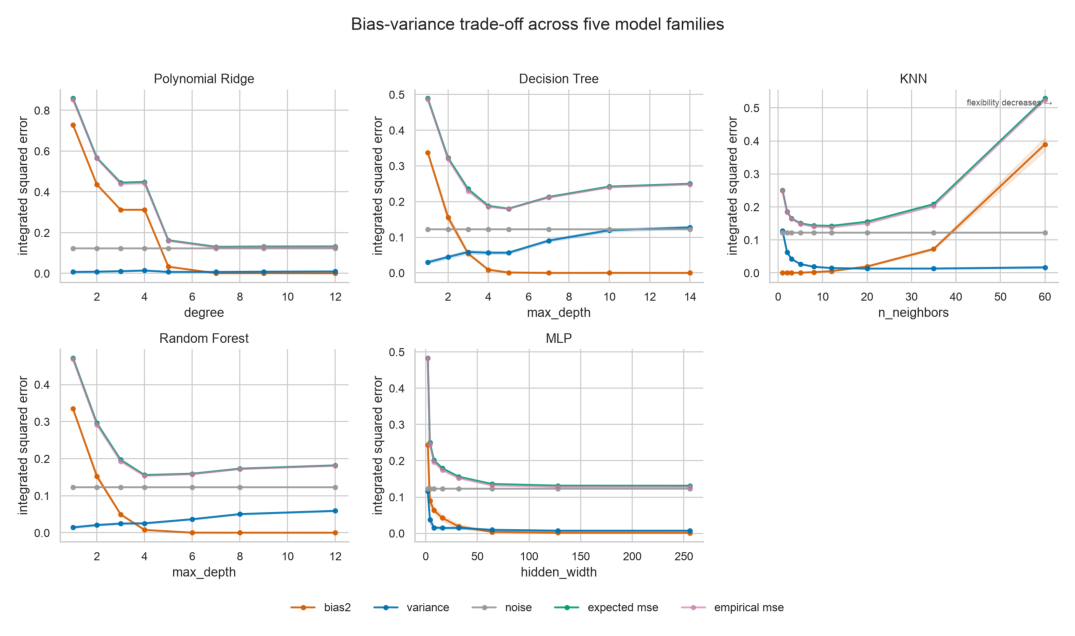

In [3]:
complexity = pd.read_csv(TABLES / "complexity_results.csv")
best = pd.read_csv(TABLES / "best_complexity_summary.csv")
display(best.round(4))
show_figure("complexity_tradeoff.png", figsize=(14, 8))


После поправки у глубокого дерева и 1-NN Bias² лежит около нуля. Прежний хвост наивной оценки почти полностью объясняется величиной `variance / n_repeats`.

Random Forest заметно стабильнее одиночного дерева сходной глубины, поскольку усредняет много деревьев. Polynomial Ridge выходит на плато. Однослойная MLP продолжает улучшаться до края основной сетки, поэтому ширины недостаточно как единственной оси сложности.


## Что меняют дополнительные данные и CV

Для дерева глубины 6 ожидается снижение variance с ростом train set. Увеличение $\sigma$ должно влиять дважды. Оно напрямую повышает Noise и затрудняет восстановление функции на конечной выборке.

GridSearchCV использует те же 160 объектов и ту же сетку сложности, что и Monte Carlo experiment. Так можно проверить, попадает ли обычный validation procedure в ту же область, где минимален expected MSE.


,study,value,value_label,bias2,bias2_raw,bias2_mc_correction,bias2_ci_low,bias2_ci_high,variance,variance_ci_low,variance_ci_high,noise,expected_mse,empirical_mse,decomposition_gap
0,sample_size,40.00,n_train,0.0014,0.0048,0.0033,-0.0015,0.0044,0.1338,0.1207,0.1468,0.1225,0.2577,0.2525,-0.0052
1,sample_size,80.00,n_train,0.0011,0.0035,0.0024,-0.0009,0.0031,0.0977,0.0920,0.1033,0.1225,0.2213,0.2126,-0.0087
2,sample_size,160.00,n_train,0.0000,0.0019,0.0018,-0.0012,0.0013,0.0737,0.0691,0.0782,0.1225,0.1962,0.1886,-0.0076
3,sample_size,320.00,n_train,0.0004,0.0016,0.0013,-0.0005,0.0012,0.0500,0.0469,0.0532,0.1225,0.1729,0.1690,-0.0039
4,noise,0.10,sigma,0.0010,0.0013,0.0003,0.0007,0.0014,0.0104,0.0098,0.0110,0.0100,0.0214,0.0205,-0.0009
5,noise,0.20,sigma,0.0005,0.0012,0.0007,0.0000,0.0010,0.0268,0.0253,0.0283,0.0400,0.0673,0.0647,-0.0026
6,noise,0.35,sigma,0.0000,0.0019,0.0018,-0.0012,0.0013,0.0737,0.0691,0.0782,0.1225,0.1962,0.1886,-0.0076
7,noise,0.60,sigma,-0.0005,0.0047,0.0052,-0.0038,0.0027,0.2081,0.1959,0.2203,0.3600,0.5676,0.5422,-0.0254
8,noise,0.90,sigma,0.0005,0.0120,0.0116,-0.0073,0.0082,0.4623,0.4361,0.4884,0.8100,1.2727,1.2194,-0.0533


,model,n_train,cv_folds,best_cv_rmse,cv_selected_complexity,decomposition_optimum,same_choice,fit_time_sec
0,Polynomial Ridge,160,5,0.3632,7,7,True,0.0549
1,MLP,160,5,0.3634,256,256,True,5.4865
2,KNN,160,5,0.3886,12,12,True,0.0540
3,Random Forest,160,5,0.4013,4,4,True,1.7443
4,Decision Tree,160,5,0.4417,4,5,False,0.0285


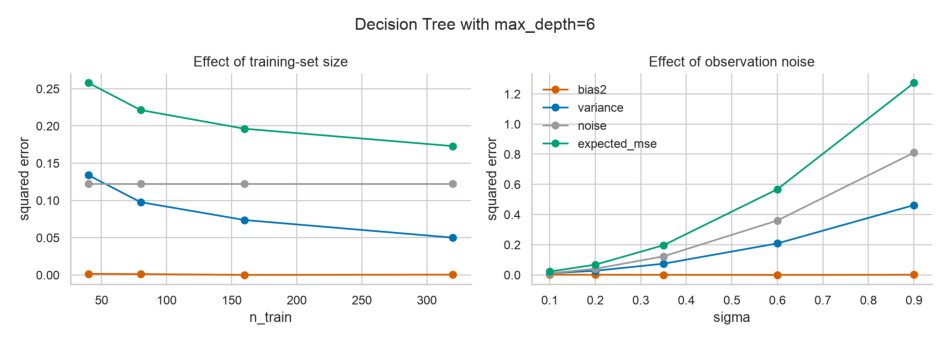

In [4]:
size_noise = pd.read_csv(TABLES / "train_size_noise_results.csv")
selection = pd.read_csv(TABLES / "cv_complexity_selection.csv")
display(size_noise.round(4))
display(selection.round(4))
show_figure("train_size_noise_effects.png", figsize=(12, 5))


CV совпадает с minimum expected MSE для четырех моделей. У Decision Tree выбор отличается на один уровень глубины. Для одной конкретной выборки это выглядит естественной погрешностью выбора, а не противоречием между двумя критериями.


## MLP как отдельный случай

Ширина сети расширена до 256, затем отдельно меняются L2 и число скрытых слоев. Это нужно потому, что число нейронов не определяет эффективную сложность само по себе. На нее одновременно влияют weight decay и момент остановки оптимизации.

История обучения строится через `partial_fit`. В отличие от повторных вызовов `fit` этот способ сохраняет optimizer state между эпохами.


,study,width,depth,alpha,n_repeats,fit_time_sec,bias2,bias2_raw,bias2_mc_correction,bias2_ci_low,bias2_ci_high,variance,variance_ci_low,variance_ci_high,noise,expected_mse,empirical_mse,decomposition_gap
0,width_alpha,16,1,0.000,20,2.1373,0.0446,0.0452,0.0006,0.0331,0.0561,0.0122,0.0088,0.0156,0.1225,0.1793,0.1763,-0.0030
1,width_alpha,64,1,0.000,20,3.0660,0.0041,0.0045,0.0004,0.0019,0.0063,0.0084,0.0062,0.0106,0.1225,0.1349,0.1330,-0.0019
2,width_alpha,128,1,0.000,20,4.2718,0.0021,0.0024,0.0003,0.0009,0.0032,0.0068,0.0056,0.0080,0.1225,0.1314,0.1295,-0.0018
3,width_alpha,256,1,0.000,20,6.7673,0.0019,0.0022,0.0003,0.0006,0.0032,0.0067,0.0055,0.0079,0.1225,0.1311,0.1290,-0.0021
4,width_alpha,16,1,0.001,20,2.1371,0.0447,0.0453,0.0006,0.0332,0.0562,0.0122,0.0088,0.0155,0.1225,0.1794,0.1763,-0.0030
5,width_alpha,64,1,0.001,20,3.0575,0.0042,0.0046,0.0004,0.0019,0.0064,0.0084,0.0062,0.0106,0.1225,0.1350,0.1332,-0.0019
6,width_alpha,128,1,0.001,20,4.2656,0.0021,0.0024,0.0003,0.0009,0.0032,0.0069,0.0057,0.0081,0.1225,0.1314,0.1296,-0.0019
7,width_alpha,256,1,0.001,20,6.6813,0.0020,0.0023,0.0003,0.0007,0.0033,0.0066,0.0054,0.0079,0.1225,0.1311,0.1293,-0.0018
8,width_alpha,16,1,0.100,20,2.1279,0.0505,0.0511,0.0005,0.0396,0.0615,0.0109,0.0080,0.0138,0.1225,0.1839,0.1809,-0.0030
9,width_alpha,64,1,0.100,20,3.0747,0.0076,0.0081,0.0005,0.0040,0.0113,0.0094,0.0059,0.0129,0.1225,0.1396,0.1382,-0.0014


,epoch,train_loss,train_rmse,val_rmse
999,1000,0.0565,0.3261,0.3737
999,1000,0.0565,0.3261,0.3737


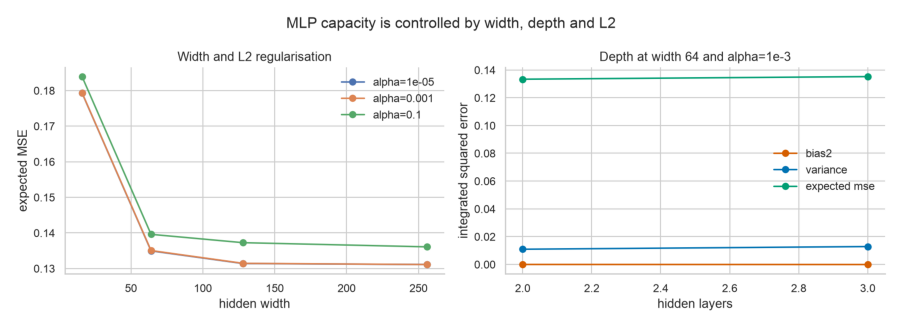

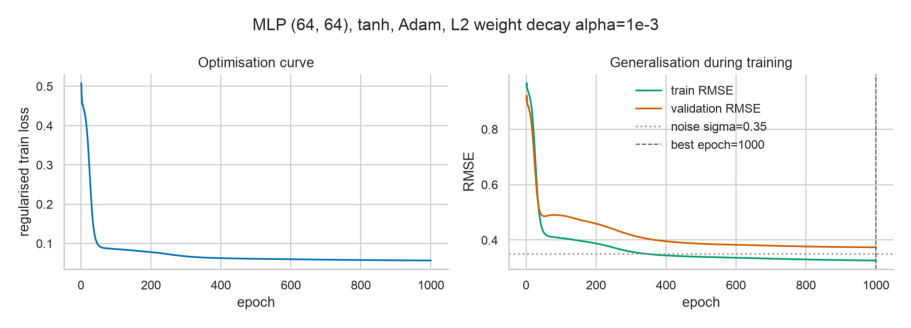

In [5]:
mlp_capacity = pd.read_csv(TABLES / "mlp_capacity_results.csv")
history = pd.read_csv(TABLES / "mlp_training_history.csv")
display(mlp_capacity.round(4))
display(history.loc[[history.val_rmse.idxmin(), len(history) - 1]].round(4))
show_figure("mlp_capacity.png", figsize=(12, 4))
show_figure("mlp_training_history.png", figsize=(12, 4))


Ширина от 128 до 256 почти не меняет expected MSE и не увеличивает variance. Значит, по этой оси нет оснований заявлять переобучение. Переход к третьему скрытому слою уже повышает variance.

К концу обучения train RMSE равен примерно 0.326 и находится ниже $\sigma=0.35$. Validation RMSE остается около 0.374. Сеть успевает подогнать часть train noise, но это почти не улучшает ошибку на отложенных данных.


## Переход к реальным данным

Diabetes достаточно мал, чтобы нестабильность моделей была заметна. California Housing дает второй режим с 5000 строками и более надежным сравнением. Модели получают общие repeated CV splits, а обучаемое масштабирование остается внутри Pipeline.

Здесь уже нельзя вычислить классический Bias², поскольку неизвестны $f(x)$ и noise variance. Поэтому сначала сравниваются CV scores, а затем отдельно изучается чувствительность к bootstrap resampling.


,dataset,rows,features,missing_values,target_mean,target_std,target_iqr_outliers
0,Diabetes,442,10,0,152.133,77.093,0
1,California Housing,5000,8,0,2.079,1.161,260


,dataset,model,rmse_mean,rmse_std,r2_mean,fit_time_sec
0,California Housing,MLP,0.570,0.019,0.758,0.470
1,California Housing,Random Forest,0.612,0.021,0.721,0.230
2,California Housing,Gradient Boosting,0.696,0.015,0.640,0.416
3,California Housing,Ridge,0.759,0.041,0.570,0.001
4,California Housing,Decision Tree,0.763,0.019,0.568,0.007
5,California Housing,Dummy,1.161,0.022,-0.001,0.000
6,Diabetes,Ridge,54.857,3.046,0.486,0.001
7,Diabetes,MLP,55.982,4.321,0.464,0.028
8,Diabetes,Gradient Boosting,56.533,3.163,0.455,0.045
9,Diabetes,Random Forest,57.349,3.916,0.438,0.080


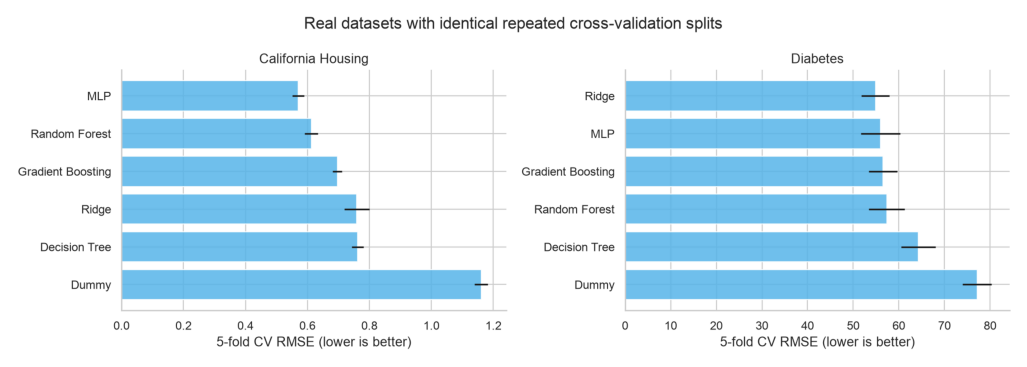

In [6]:
overview = pd.read_csv(TABLES / "real_data_overview.csv")
real_summary = pd.read_csv(TABLES / "real_model_summary.csv")
display(overview.round(3))
display(real_summary.round(3))
show_figure("real_model_comparison.png", figsize=(13, 5))


На Diabetes различия Ridge, MLP и Gradient Boosting меньше наблюдаемого разброса между folds. На California Housing MLP и Random Forest заметно превосходят linear baseline и Dummy. Увеличение датасета делает ранжирование гораздо устойчивее.


## Как выглядит сложность на Diabetes

Одномерная синтетика хорошо показывает механизм, но не гарантирует такую же форму кривых на десяти признаках. Поэтому на общих bootstrap indices меняются alpha Ridge, глубина дерева, число соседей, а также ширина и alpha MLP.


,model,complexity_label,complexity,alpha,depth,mean_prediction_mse,bootstrap_variance,mean_bootstrap_mse,identity_gap,n_bootstrap,fit_time_sec
0,Ridge,alpha,0.01,NaN,NaN,2778.479,105.616,2884.095,-0.0,30,0.046
1,Ridge,alpha,0.10,NaN,NaN,2779.535,104.514,2884.049,-0.0,30,0.045
2,Ridge,alpha,1.00,NaN,NaN,2787.399,97.590,2884.989,0.0,30,0.045
3,Ridge,alpha,10.00,NaN,NaN,2802.160,83.673,2885.833,-0.0,30,0.046
4,Ridge,alpha,100.00,NaN,NaN,2836.596,51.089,2887.686,0.0,30,0.046
5,Decision Tree,max_depth,1.00,NaN,NaN,3860.090,713.222,4573.312,0.0,30,0.027
6,Decision Tree,max_depth,2.00,NaN,NaN,3400.678,602.379,4003.057,-0.0,30,0.030
7,Decision Tree,max_depth,3.00,NaN,NaN,3354.080,838.925,4193.005,-0.0,30,0.033
8,Decision Tree,max_depth,5.00,NaN,NaN,3381.089,1487.870,4868.959,-0.0,30,0.038
9,Decision Tree,max_depth,8.00,NaN,NaN,3451.753,1934.633,5386.386,0.0,30,0.042


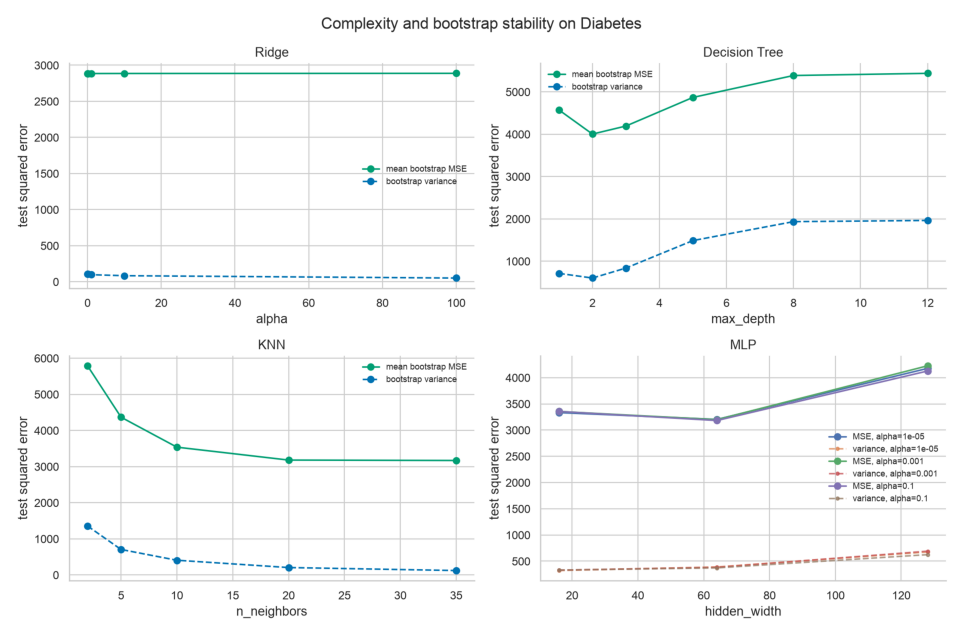

In [7]:
diabetes_complexity = pd.read_csv(TABLES / "diabetes_complexity.csv")
display(diabetes_complexity.round(3))
show_figure("diabetes_complexity.png", figsize=(13, 8))


После глубины 2 variance дерева быстро растет. У Ridge усиление regularisation уменьшает variance при почти неизменном среднем bootstrap MSE. Для MLP ширина 64 устойчивее ширины 128 при всех рассмотренных alpha.

KNN снова требует осторожного чтения оси. Движение вправо означает больше соседей и более сильное сглаживание, поэтому variance закономерно падает.


## Что именно измеряет bootstrap

Для фиксированного test set prediction matrix удовлетворяет точному тождеству

$$
\frac{1}{B}\sum_b MSE(y, \hat f_b)
=
MSE(y, \bar f)
+
\frac{1}{n}\sum_i Var_b(\hat f_b(x_i)).
$$

Первый член не является Bias². Он объединяет отличие среднего прогноза от наблюдаемых targets, test noise и эффект выбранного split. Второй член показывает только нестабильность при перевыборке train data.


,dataset,model,mean_prediction_mse,bootstrap_variance,mean_bootstrap_mse,identity_gap,n_bootstrap,fit_time_sec
0,Diabetes,Dummy,5485.225079,18.426795,5503.651874,0.0,60,0.014156
1,Diabetes,Ridge,2799.237208,83.883096,2883.120305,-0.0,60,0.091722
2,Diabetes,Decision Tree,3332.069536,1153.341667,4485.411203,0.0,60,0.071285
3,Diabetes,Random Forest,3175.683521,299.697173,3475.380693,-0.0,60,5.853233
4,Diabetes,Gradient Boosting,2940.660288,198.420927,3139.081216,-0.0,60,2.462553
5,Diabetes,MLP,2748.749926,421.610958,3170.360884,0.0,60,4.251786
6,California Housing,Dummy,1.336104,0.000382,1.336485,-0.0,60,0.018622
7,California Housing,Ridge,0.778181,1.821309,2.599490,-0.0,60,0.102390
8,California Housing,Decision Tree,0.498931,0.105428,0.604360,-0.0,60,0.396830
9,California Housing,Random Forest,0.381497,0.022404,0.403901,0.0,60,14.183679


maximum absolute identity gap 1.1368683772161605e-12


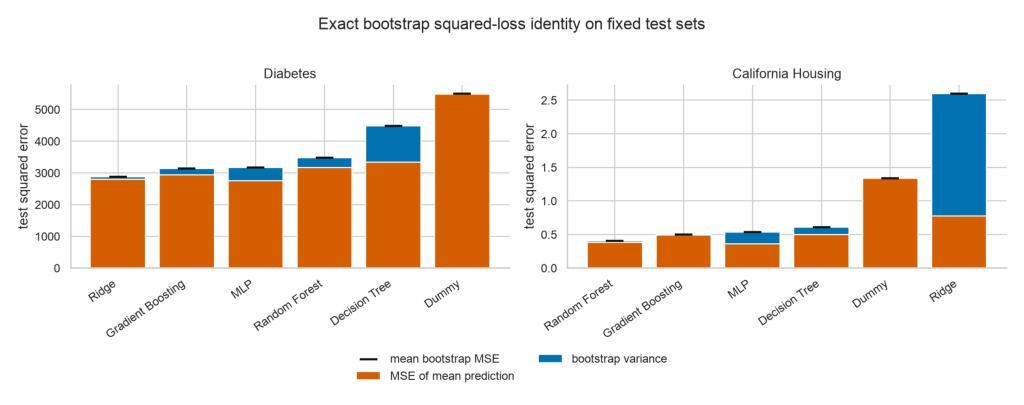

In [8]:
bootstrap = pd.read_csv(TABLES / "real_bootstrap_identity.csv")
display(bootstrap.round(6))
print("maximum absolute identity gap", bootstrap.identity_gap.abs().max())
show_figure("real_bootstrap_identity.png", figsize=(13, 5))


## Что получилось

Decision Tree, KNN и Random Forest дают наиболее явный bias-variance trade-off. Polynomial Ridge после достаточной степени выходит на плато. Для однослойной MLP рост ширины сам по себе не приводит к росту variance, но дополнительная глубина и многомерный Diabetes показывают менее устойчивые режимы.

Дополнительные данные снижают variance, а большой observation noise становится главной частью ошибки. CV обычно выбирает тот же участок сложности, что и Monte Carlo experiment на выборке сопоставимого размера.

Главное ограничение реальной части связано не с числом моделей, а с отсутствием известной regression function. Bootstrap разделяет ошибку среднего прогноза и нестабильность, но не восстанавливает Bias² и irreducible noise по отдельности.
